# Tutorial on Multi-fidelity Shape Optimisation of a Cyclist Helmet

This tutorial provides a step-by-step tutorial on how to run shape optimisation using the Bayesian Optimisation method with a Multi-Fidelity Gaussian Process (MF-GP) and a multi-fidelity acquisition function.

_Please note that running the full notebook requires OpenFOAM, Python packages, and the optimisation libraries listed in the following cells._

## Overview

This tutorial performs multi-fidelity shape optimisation for a hemispherical geometry using Bayesian optimisation. The optimisation uses two Computational Fluid Dynamics (CFD) models solved in OpenFOAM, an open-source CFD solver. The low-fidelity model uses a cheaper OpenFOAM case, while the high-fidelity model uses a more expensive OpenFOAM case. The multi-fidelity framework combines information from both models, which allows the optimiser to use many cheaper low-fidelity samples and fewer high-fidelity samples.

## Optimisation Objective

We are optimising a simplified helmet shape to achieve the minimum drag coefficient $C_d$.

<div style="text-align: center;">
    <img src="img/geometry.png" width="600">
    <p style="text-align: center;"><b>Figure 1.</b> Comparison of the real cyclist helmet (left) and the simplified model (right).</p>
</div>

## Boundary Conditions

The cyclist helmet is mounted on a lower wall, which is defined as a no-slip wall boundary condition. This allows the boundary layer to develop along the lower wall. To reduce the computational time, a symmetry plane is used. The tunnel surrounding the geometry is defined using a slip wall condition.

<div style="text-align: center;">
    <img src="img/boundary.png" width="600">
    <p style="text-align: center;"><b>Figure 2.</b> Boundary conditions.</p>
</div>

## Design Variables

A free-form deformation technique based on radial basis function $^1$ interpolation is used to deform the geometry. The rear-end part of the helmet is used as the focus region for the optimisation. The geometry is controlled by two design variables, `x1` and `x2`. These variables are first handled in a normalised range between `0` and `1`.

`x1` controls the lateral deformation of selected control points.

`x2` controls the vertical deformation of selected control points.

<div style="text-align: center;">
    <img src="img/deformation.png" width="600">
    <p style="text-align: center;"><b>Figure 3.</b> Example of the lattice points movement and the resulting deformed helmet.</p>
</div>

## Low-Fidelity and High-Fidelity Comparison

The low-fidelity simulation in this case uses a model that is not highly accurate in predicting drag, but it provides a significantly faster computational time. Even so, the overall objective function can still be estimated from this quicker optimisation. The high-fidelity simulation then uses a more accurate method to predict $C_d$, although the simulation time increases significantly. The comparison between LF and HF is summarised in the following table.

| Indicator | LF | HF |
| :--- | :--- | :--- |
| Mesh | 46,297 cells | 1.7 million cells | 
| Turbulence model | $k-\varepsilon$ | $k-\omega SST$ |
| $C_d$ Baseline | 0.267 | 0.176 |
| Computational time (20-core parallel) | 1 minutes | 11 minutes |
| Relative Cost | 1 | 11 |

<div style="text-align: center;">
    <img src="img/mesh.png" width="600">
    <p style="text-align: center;"><b>Figure 4.</b> Visualisation of the coarse mesh (left) as the LF case and the fine mesh (right) as the HF case.</p>
</div>

## Step-by-Step on How to Do It

### Project Folder

The project folder consists of several files and folders. The `helmetMF_Tutorial.ipynb` file is the main optimisation code. The `LF` folder contains the OpenFOAM low-fidelity simulation case, while the `HF` folder contains the high-fidelity OpenFOAM test case. The `img` folder contains figures used for visualisation in this tutorial.

After running the optimisation, the code will create folders named `optimisation1`, `optimisation2`, and so on until the final iteration. It will also create an `optimisationResults` folder, which saves the generated optimisation figures, and a temporary `optimisedCase` folder, which contains the simulation that is currently running.

```text
Tutorial_Helmet_MFShapeOptimisation/
├── helmetMF_Tutorial.ipynb
├── LF/
│   ├── 0.orig/
│   ├── constant/
│   ├── system/
│   └── hemisphereOrig.stl
├── HF/
│   ├── 0.orig/
│   ├── constant/
│   └── system/
│   └── hemisphereOrig.stl
├── initialsamples.csv
└── img/
```

### 1. Importing Libraries

We start by importing the Python libraries required for file handling, numerical calculations, plotting, surrogate modelling, multi-fidelity Bayesian optimisation, geometry deformation, STL file handling, and Latin Hypercube Sampling.

The main packages used are NumPy, pandas, matplotlib, PyGeM$^1$, Emukit$^2$, GPy$^3$, and smithers.

In [1]:
import os
import sys
import subprocess
import glob
from pathlib import Path
import pandas as pd
import numpy as np
import emukit
import matplotlib.pyplot as plt
from emukit.multi_fidelity.convert_lists_to_array import convert_xy_lists_to_arrays
from emukit.core import ParameterSpace, ContinuousParameter, InformationSourceParameter
from emukit.multi_fidelity.models.linear_model import GPyLinearMultiFidelityModel
import GPy
from emukit.multi_fidelity.kernels.linear_multi_fidelity_kernel import LinearMultiFidelityKernel
from emukit.model_wrappers import GPyMultiOutputWrapper
from emukit.core.loop.user_function import MultiSourceFunctionWrapper
from emukit.bayesian_optimization.acquisitions.entropy_search import MultiInformationSourceEntropySearch
from emukit.core.acquisition import Acquisition
from emukit.core.loop import FixedIntervalUpdater, OuterLoop, SequentialPointCalculator
from emukit.core.loop.loop_state import create_loop_state
from emukit.core.optimization.multi_source_acquisition_optimizer import MultiSourceAcquisitionOptimizer
from emukit.core.optimization import GradientAcquisitionOptimizer
from emukit.bayesian_optimization.acquisitions.max_value_entropy_search import MUMBO
from pygem import RBF
from smithers import io

## 2. Setting the Working Directory and Result Folder

Then, we need to define the main working directory, the temporary OpenFOAM case folder, and the folder where the optimisation results will be saved.

A folder named `optimisationResults` is created automatically if it does not already exist. This folder stores plots, CSV files, convergence history, and sampled design points.

In [2]:
working_dir = Path(os.getcwd())
print(working_dir)
sys.path.append(str(working_dir))
optimised_case_dir = working_dir / "optimisedCase"
resultFolder = working_dir / "optimisationResults"

/home/y95228da/Desktop/AIRTUK/package-v1/airtuk-tutorials-main/tutorials/MFM_BO


## 3. Defining Optimisation Settings

After that, the lower and upper bounds of the two design variables, `x1` and `x2`, are defined.

This step also sets the number of initial low-fidelity and high-fidelity samples, the number of optimisation iterations, and the relative cost of each fidelity.

In [3]:
LFinitialSamples = 16
HFinitialSamples = 4
lowerBound_x1 = 0.03
upperBound_x1 = 0.1
lowerBound_x2 = 0.03
upperBound_x2 = 0.09
numberOfIteration = 10
lower_bounds_sampling = [lowerBound_x1, upperBound_x1] 
upper_bounds_sampling = [lowerBound_x2, upperBound_x2]

#Set up costs for low and high fidelity
low_fidelity_cost = 1
high_fidelity_cost = 2.5

LB = np.array([lowerBound_x1, lowerBound_x2], dtype=float)
UB = np.array([upperBound_x1, upperBound_x2], dtype=float)

## 4. Normalising and Unnormalising Design Variables

The optimiser works with `x1` and `x2` in a normalised range from `0` to `1`.

The function `normalize_nd` converts the real design variables into the normalised range.

The function `unnormalize_nd` converts the normalised variables back into their real physical values.

In [4]:
def normalize_nd(X, lb=LB, ub=UB):
    X = np.atleast_2d(X).astype(float)
    return (X - lb) / (ub - lb)

def unnormalize_nd(Xn, lb=LB, ub=UB):
    Xn = np.atleast_2d(Xn).astype(float)
    return lb + Xn * (ub - lb)

## 5. Low-Fidelity Objective Function

The function `objective_low` evaluates a design point using the low-fidelity OpenFOAM case.

For each selected design point, the code copies the LF folder into a temporary folder called `optimisedCase`.

It then updates the geometry using the current values of `x1` and `x2`, runs the OpenFOAM simulation, reads the final drag coefficient, and returns it to the optimiser.

In [5]:
def objective_low(Xn):
    x  = unnormalize_nd(np.atleast_2d(Xn)[:, :2])
    x1_i = x[:, [0]]; x2_i = x[:, [1]]
    n = x.shape[0]
    drag_values = [] 

    for i in range(n):  
        x1_i, x2_i = x[i, 0], x[i, 1]
        print(f"Processing sample {i+1}/{n}, x1 = {x1_i}, x2 = {x2_i}")
        
        os.chdir(working_dir)
        subprocess.run(['cp', '-r', 'LF', 'optimisedCase'], check=True)
        os.chdir(os.path.join(working_dir, 'optimisedCase'))
        print(f"Processed x1 (before generating STL): {x1_i}, Type: {type(x1_i)}")
        print(f"Processed x2 (before generating STL): {x2_i}, Type: {type(x2_i)}")
        # ======================================================
        # Geometry deformation using PyGeM 
        # First, we create .prm file used to deform geometry
        # ======================================================
        original_control_points = np.array([
            [-0.075, -0.075,  0.   ],
            [-0.075, -0.075,  0.075],
            [-0.075,  0.,     0.   ],
            [-0.075,  0.,     0.075],
            [-0.075,  0.075,  0.   ],
            [-0.075,  0.075,  0.075],
            [ 0.,    -0.075,  0.   ],
            [ 0.,    -0.075,  0.075],
            [ 0.,     0.,     0.   ],
            [ 0.,     0.,     0.075],
            [ 0.,     0.075,  0.   ],
            [ 0.,     0.075,  0.075],
            [ 0.075, -0.075,  0.   ],
            [ 0.075, -0.075,  0.075],
            [ 0.075,  0.,     0.   ],
            [ 0.075,  0.,     0.075],
            [ 0.075,  0.075,  0.   ],
            [ 0.075,  0.075,  0.075]
        ])

        deformed_control_points = np.array([
            [-0.075, -0.075,  0.   ],
            [-0.075, -0.075,  0.075],
            [-0.075,  0.,     0.   ],
            [-0.075,  0.,     0.075],
            [-0.075,  0.075,  0.   ],
            [-0.075,  0.075,  0.075],
            [ 0.,    -0.075,  0.   ],
            [ 0.,    -0.075,  0.075],
            [ 0.,     0.,     0.   ],
            [ 0.,     0.,     0.075],
            [ 0.,     0.075,  0.   ],
            [ 0.,     0.075,  0.075],
            [ 0.075, -x1_i,  0.   ],
            [ 0.075, -x1_i,  x2_i],
            [ 0.075,  0.,     0.   ],
            [ 0.075,  0.,     x2_i],
            [ 0.075,  x1_i,  0.   ],
            [ 0.075,  x1_i,  x2_i]
        ])

        lines = ["[Radial Basis Functions]"]
        lines.append("basis function: gaussian_spline")
        lines.append("radius: 0.3")
        lines.append("")
        lines.append("[Control points]")
        
        first = original_control_points[0]
        lines.append(f"original control points: {first[0]} {first[1]} {first[2]}")
        for point in original_control_points[1:]:
            lines.append(f"    {point[0]} {point[1]} {point[2]}")         
        lines.append("")
        first = deformed_control_points[0]
        lines.append(f"deformed control points: {first[0]} {first[1]} {first[2]}")
        for point in deformed_control_points[1:]:
            lines.append(f"    {point[0]} {point[1]} {point[2]}")
        prm_content = "\n".join(lines)

        output_path = os.path.join(str(working_dir), "optimisedCase", "hemisphere_parameters.prm")

        with open(output_path, "w") as f:
            f.write(prm_content)

        print(f"prm file saved at: {output_path}")
        
        # ======================================================
        # Then, we deform the baseline shape (hemisphereOrig.stl) to the deformed shape, save it to the openfoam test case folder
        # ======================================================
        stl_filename = "hemisphereOrig.stl"
        original_stl = io.STLHandler.read(stl_filename)
        original_points = original_stl['points']
        cells = original_stl['cells']

        rbf = RBF()
        rbf.read_parameters('hemisphere_parameters.prm')

        deformed_points = rbf(original_points.copy())

        deformed_stl = original_stl.copy()
        deformed_stl['points'] = deformed_points
        
        tri_surface_dir = os.path.join(working_dir, 'optimisedCase', 'constant', 'triSurface')
        os.makedirs(tri_surface_dir, exist_ok=True)
        stl_file_path = os.path.join(tri_surface_dir, 'hemisphere.stl')
        
        io.STLHandler.write(stl_file_path, deformed_stl)

        if os.path.exists(stl_file_path):
            print(f" STL file saved successfully: {stl_file_path}")
        else:
            print(f" STL file not found: {stl_file_path}")
            
        # ======================================================
        # Since the shape is deformed, we need to calculate and update the frontal area
        # ======================================================
        def compute_frontal_area(points, cells):
            area = 0.0
            for cell in cells:
                i0, i1, i2 = cell
                p0, p1, p2 = points[i0], points[i1], points[i2]

                v1 = p1 - p0
                v2 = p2 - p0

                normal = np.cross(v1, v2)
                area += abs(normal[0]) / 2.0 

            return area / 2.0

        tri_surface_dir = os.path.join(working_dir, 'optimisedCase', 'constant', 'triSurface')
        stl_file_path = os.path.join(tri_surface_dir, 'hemisphere.stl')
        stl_data = io.STLHandler.read(stl_file_path)
        points = stl_data['points']
        cells = stl_data['cells']
        frontal_area = compute_frontal_area(points, cells)

        # Output
        print(f"Calculated projected area in streamwise (X) direction: {frontal_area:.6f} m^2")
        
        # ======================================================
        # Updating the value of frontal area, and re-write forceCoeffDict
        # ======================================================
        def generate_force_coeff_dict(frontal_area, output_path):
            force_dict_content = f"""/*--------------------------------*- C++ -*----------------------------------*\\
        | =========                 |                                                 |
        | \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox           |
        |  \\\\    /   O peration     | Version:  Aan Version                                 |
        |   \\\\  /    A nd           | Website:  www.openfoam.com                      |
        |    \\\\/     M anipulation  |                                                 |
        \\*---------------------------------------------------------------------------*/
        
        forceCoeffs1
        {{
            type            forceCoeffs;
        
            libs            (forces);
        
            writeControl    timeStep;
            timeInterval    1;
        
            log             yes;
        
            patches         (hemisphere);
            rho             rhoInf;      
            rhoInf          1;           
            liftDir         (0 0 1);
            dragDir         (1 0 0);
            CofR            (0 0 0); 
            pitchAxis       (0 1 0);
            magUInf         5.14;
            lRef            0.15;      
            Aref            {frontal_area:.6f};     
        }}
        """
            with open(output_path, 'w') as f:
                f.write(force_dict_content)
            if os.path.exists(output_path):
                print(f"forceCoeffDict successfully written to:\n   {output_path}")
                print(f"Aref updated to: {frontal_area:.6f} m²")
            else:
                print(f"Failed to write forceCoeffDict at:\n   {output_path}")
        
        system_dir = os.path.join(working_dir, 'optimisedCase', 'system')
        os.makedirs(system_dir, exist_ok=True)
        force_coeff_dict_path = os.path.join(system_dir, 'forceCoeffs')
        generate_force_coeff_dict(frontal_area, force_coeff_dict_path)

        
                
        # ======================================================
        # Updating the decomposeDict based on the available no of processors
        # ======================================================
        # Determine number of processors
        total_processors = os.cpu_count()
        # Use 50% of available processors
        num_processors = max(1, total_processors // 2)
        # Ensure the number of processors is even
        if num_processors % 2 != 0:
            num_processors -= 1

        def generate_decompose_par_dict(num_processors, output_path):

            n_x = num_processors // 2
        
            decompose_dict_content = f"""/*--------------------------------*- C++ -*----------------------------------*\\
        | =========                 |                                                 |
        | \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox           |
        |  \\\\    /   O peration     | Version:  v2212                                 |
        |   \\\\  /    A nd           | Website:  www.openfoam.com                      |
        |    \\\\/     M anipulation  |                                                 |
        \\*---------------------------------------------------------------------------*/
        FoamFile
        {{
            version     2.0;
            format      ascii;
            class       dictionary;
            object      decomposeParDict;
        }}
        // * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //
        
        numberOfSubdomains {num_processors};
        
        method          simple;
        
        simpleCoeffs
        {{
            n           ({n_x} 2 1);
        }}
        
        
        // ************************************************************************* //
        """
        
            with open(output_path, 'w') as f:
                f.write(decompose_dict_content)
        
            if os.path.exists(output_path):
                print(
                    f"decomposeParDict successfully written to:\n"
                    f"   {output_path}"
                )
                print(f"numberOfSubdomains: {num_processors}")
                print(f"simpleCoeffs n: ({n_x} 2 1)")
            else:
                print(
                    f"Failed to write decomposeParDict at:\n"
                    f"   {output_path}"
                )
        
        
        # Path to system directory
        system_dir = os.path.join(
            working_dir,
            'optimisedCase',
            'system'
        )
        
        os.makedirs(system_dir, exist_ok=True)
        
        # Path to decomposeParDict
        decompose_dict_path = os.path.join(
            system_dir,
            'decomposeParDict'
        )
        
        # Generate the dictionary
        generate_decompose_par_dict(
            num_processors,
            decompose_dict_path
        )

        # ======================================================
        # Running OpenFOAM simulation
        # ======================================================
        
        def find_openfoam23():
            search_paths = [
                "/usr/lib/openfoam/openfoam23*/etc/bashrc",
                "/usr/local/openfoam/openfoam23*/etc/bashrc",
                os.path.expanduser("~/OpenFOAM/OpenFOAM-23*/etc/bashrc"),
            ]
        
            candidates = []
        
            for pattern in search_paths:
                candidates.extend(glob.glob(pattern))
        
            if not candidates:
                raise RuntimeError(
                    "Could not find an OpenFOAM 23.x installation."
                )
        
            return sorted(candidates)[-1]
        
        
        def run_openfoam(commands):
            openfoam_bashrc = find_openfoam23()
        
            print(f"Using OpenFOAM: {openfoam_bashrc}")
        
            bash_commands = [
                f'source "{openfoam_bashrc}"',
                *commands
            ]
        
            subprocess.run(
                "\n".join(bash_commands),
                shell=True,
                executable="/bin/bash",
                cwd=optimised_case_dir,
                check=True
            )
        
        
        run_openfoam([
            "cp -r 0.orig 0",
            "blockMesh > blockMesh.log 2>&1",
            "surfaceFeatureExtract > surfaceFeatureExtract.log 2>&1",
            "decomposePar -force > decomposePar.log 2>&1",
            f"mpirun -np {num_processors} -- snappyHexMesh -parallel -overwrite > snappyHexMesh.log 2>&1",
            "reconstructParMesh -constant > reconstructParMesh.log 2>&1",
            "checkMesh > checkMesh.log 2>&1",
            "rm -rf processor*",
            "decomposePar > decomposePar.log 2>&1",
            f"mpirun -np {num_processors} -- simpleFoam -parallel > simpleFoam_parallel.log 2>&1",
            "reconstructPar > reconstructPar.log 2>&1",
            "touch a.foam",
            "rm -rf processor*",
        ])
        
        # ======================================================
        # After the simulation finished, we read the calculated Cd
        # ======================================================
        force_file = working_dir / "optimisedCase/postProcessing/forceCoeffs1/0/coefficient.dat"
        with open(force_file,'r') as file:
            lines = file.readlines()
        last_line = lines[-1]
        columns = last_line.split()
        drag = float(columns[1])
        print(f"LF Drag value for sample {i+1}: {drag}")

        drag_values.append(drag)
        os.chdir(working_dir)

        # ======================================================
        # Renaming the optimisation folder to optimisation1, optimisation2, etc.
        # ======================================================
        cycle = 1
        while True:
            cycleFolder = f"optimisation{cycle}"
            if not os.path.exists(cycleFolder):
                break
            cycle += 1
        os.rename("optimisedCase", cycleFolder)

    dragCoeff = np.array(drag_values).reshape(n, 1)

    print(f'LF Drag Coeff return = {dragCoeff}')
    print(f'Type of LF return: {type(dragCoeff)}')
    print(f'Shape of LF return: {dragCoeff.shape}') 
    
    np.savetxt('LF_results.csv', dragCoeff, delimiter=',', header="LF Drag Coefficients", comments='')

    return dragCoeff


## 6. High-Fidelity Objective Function

The function `objective_high` works in the same way as the low-fidelity function, but it uses the HF OpenFOAM case instead. This means the same geometry deformation and CFD workflow are applied, but using the high-fidelity mesh and solver setup. The returned value is the high-fidelity drag coefficient.

In [6]:
def objective_high(Xn):
    x  = unnormalize_nd(np.atleast_2d(Xn)[:, :2])
    x1_i = x[:, [0]]; x2_i = x[:, [1]]
    n = x.shape[0]
    drag_values = []  

    for i in range(n):  
        x1_i, x2_i = x[i, 0], x[i, 1]
        print(f"Processing sample {i+1}/{n}, x1 = {x1_i}, x2 = {x2_i}")
        
        os.chdir(working_dir)
        subprocess.run(['cp', '-r', 'HF', 'optimisedCase'], check=True)
        os.chdir(os.path.join(working_dir, 'optimisedCase'))
        
        print(f"Processed x1 (before generating STL): {x1_i}, Type: {type(x1_i)}")
        print(f"Processed x2 (before generating STL): {x2_i}, Type: {type(x2_i)}")
        
        # ======================================================
        # Geometry deformation using PyGeM 
        # First, we create .prm file used to deform geometry
        # ======================================================

        original_control_points = np.array([
            [-0.075, -0.075,  0.   ],
            [-0.075, -0.075,  0.075],
            [-0.075,  0.,     0.   ],
            [-0.075,  0.,     0.075],
            [-0.075,  0.075,  0.   ],
            [-0.075,  0.075,  0.075],
            [ 0.,    -0.075,  0.   ],
            [ 0.,    -0.075,  0.075],
            [ 0.,     0.,     0.   ],
            [ 0.,     0.,     0.075],
            [ 0.,     0.075,  0.   ],
            [ 0.,     0.075,  0.075],
            [ 0.075, -0.075,  0.   ],
            [ 0.075, -0.075,  0.075],
            [ 0.075,  0.,     0.   ],
            [ 0.075,  0.,     0.075],
            [ 0.075,  0.075,  0.   ],
            [ 0.075,  0.075,  0.075]
        ])

        deformed_control_points = np.array([
            [-0.075, -0.075,  0.   ],
            [-0.075, -0.075,  0.075],
            [-0.075,  0.,     0.   ],
            [-0.075,  0.,     0.075],
            [-0.075,  0.075,  0.   ],
            [-0.075,  0.075,  0.075],
            [ 0.,    -0.075,  0.   ],
            [ 0.,    -0.075,  0.075],
            [ 0.,     0.,     0.   ],
            [ 0.,     0.,     0.075],
            [ 0.,     0.075,  0.   ],
            [ 0.,     0.075,  0.075],
            [ 0.075, -x1_i,  0.   ],
            [ 0.075, -x1_i,  x2_i],
            [ 0.075,  0.,     0.   ],
            [ 0.075,  0.,     x2_i],
            [ 0.075,  x1_i,  0.   ],
            [ 0.075,  x1_i,  x2_i]
        ])

        lines = ["[Radial Basis Functions]"]
        lines.append("basis function: gaussian_spline")
        lines.append("radius: 0.3")
        lines.append("")
        lines.append("[Control points]")

        first = original_control_points[0]
        lines.append(f"original control points: {first[0]} {first[1]} {first[2]}")
        for point in original_control_points[1:]:
            lines.append(f"    {point[0]} {point[1]} {point[2]}")
            
        lines.append("")

        first = deformed_control_points[0]
        lines.append(f"deformed control points: {first[0]} {first[1]} {first[2]}")
        for point in deformed_control_points[1:]:
            lines.append(f"    {point[0]} {point[1]} {point[2]}")
        prm_content = "\n".join(lines)
        output_path = os.path.join(str(working_dir), "optimisedCase", "hemisphere_parameters.prm")
       
        with open(output_path, "w") as f:
            f.write(prm_content)

        print(f"prm file saved at: {output_path}")
        
        # ======================================================
        # Then, we deform the baseline shape (hemisphereOrig.stl) to the deformed shape, save it to the openfoam test case folder
        # ======================================================

        stl_filename = "hemisphereOrig.stl"
        original_stl = io.STLHandler.read(stl_filename)
        original_points = original_stl['points']
        cells = original_stl['cells']

        rbf = RBF()
        rbf.read_parameters('hemisphere_parameters.prm')
        deformed_points = rbf(original_points.copy())
        deformed_stl = original_stl.copy()
        deformed_stl['points'] = deformed_points
        
        tri_surface_dir = os.path.join(working_dir, 'optimisedCase', 'constant', 'triSurface')
        os.makedirs(tri_surface_dir, exist_ok=True) 
        stl_file_path = os.path.join(tri_surface_dir, 'hemisphere.stl')
        
        io.STLHandler.write(stl_file_path, deformed_stl)

        if os.path.exists(stl_file_path):
            print(f" STL file saved successfully: {stl_file_path}")
        else:
            print(f" STL file not found: {stl_file_path}")
            
        # ======================================================
        # Since the shape is deformed, we need to calculate and update the frontal area
        # ======================================================
        def compute_frontal_area(points, cells):
            area = 0.0
            for cell in cells:
                i0, i1, i2 = cell
                p0, p1, p2 = points[i0], points[i1], points[i2]

                v1 = p1 - p0
                v2 = p2 - p0

                normal = np.cross(v1, v2)
                area += abs(normal[0]) / 2.0 
            return area / 2.0

        tri_surface_dir = os.path.join(working_dir, 'optimisedCase', 'constant', 'triSurface')
        stl_file_path = os.path.join(tri_surface_dir, 'hemisphere.stl')
        stl_data = io.STLHandler.read(stl_file_path)
        points = stl_data['points']
        cells = stl_data['cells']
        frontal_area = compute_frontal_area(points, cells)

        # Output
        print(f"Calculated projected area in streamwise (X) direction: {frontal_area:.6f} m^2")
        
        # ======================================================
        # Updating the value of frontal area, and re-write forceCoeffDict
        # ======================================================
        
        def generate_force_coeff_dict(frontal_area, output_path):
            force_dict_content = f"""/*--------------------------------*- C++ -*----------------------------------*\\
        | =========                 |                                                 |
        | \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox           |
        |  \\\\    /   O peration     | Version:  Aan Version                                 |
        |   \\\\  /    A nd           | Website:  www.openfoam.com                      |
        |    \\\\/     M anipulation  |                                                 |
        \\*---------------------------------------------------------------------------*/
        
        forceCoeffs1
        {{
            type            forceCoeffs;
        
            libs            (forces);
        
            writeControl    timeStep;
            timeInterval    1;
        
            log             yes;
        
            patches         (hemisphere);
            rho             rhoInf;      
            rhoInf          1;           
            liftDir         (0 0 1);
            dragDir         (1 0 0);
            CofR            (0 0 0); 
            pitchAxis       (0 1 0);
            magUInf         5.14;
            lRef            0.15;      
            Aref            {frontal_area:.6f};     
        }}
        """
            with open(output_path, 'w') as f:
                f.write(force_dict_content)
            if os.path.exists(output_path):
                print(f"forceCoeffDict successfully written to:\n   {output_path}")
                print(f"Aref updated to: {frontal_area:.6f} m²")
            else:
                print(f"Failed to write forceCoeffDict at:\n   {output_path}")
        
        system_dir = os.path.join(working_dir, 'optimisedCase', 'system')
        os.makedirs(system_dir, exist_ok=True)
        force_coeff_dict_path = os.path.join(system_dir, 'forceCoeffs')
        generate_force_coeff_dict(frontal_area, force_coeff_dict_path)

                
        # ======================================================
        # Updating the decomposeDict based on the available no of processors
        # ======================================================
        # Determine number of processors
        total_processors = os.cpu_count()
        # Use 50% of available processors
        num_processors = max(1, total_processors // 2)
        # Ensure the number of processors is even
        if num_processors % 2 != 0:
            num_processors -= 1

        def generate_decompose_par_dict(num_processors, output_path):

            n_x = num_processors // 2
        
            decompose_dict_content = f"""/*--------------------------------*- C++ -*----------------------------------*\\
        | =========                 |                                                 |
        | \\\\      /  F ield         | OpenFOAM: The Open Source CFD Toolbox           |
        |  \\\\    /   O peration     | Version:  v2212                                 |
        |   \\\\  /    A nd           | Website:  www.openfoam.com                      |
        |    \\\\/     M anipulation  |                                                 |
        \\*---------------------------------------------------------------------------*/
        FoamFile
        {{
            version     2.0;
            format      ascii;
            class       dictionary;
            object      decomposeParDict;
        }}
        // * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * * //
        
        numberOfSubdomains {num_processors};
        
        method          simple;
        
        simpleCoeffs
        {{
            n           ({n_x} 2 1);
        }}
        
        
        // ************************************************************************* //
        """
        
            with open(output_path, 'w') as f:
                f.write(decompose_dict_content)
        
            if os.path.exists(output_path):
                print(
                    f"decomposeParDict successfully written to:\n"
                    f"   {output_path}"
                )
                print(f"numberOfSubdomains: {num_processors}")
                print(f"simpleCoeffs n: ({n_x} 2 1)")
            else:
                print(
                    f"Failed to write decomposeParDict at:\n"
                    f"   {output_path}"
                )
        
        
        # Path to system directory
        system_dir = os.path.join(
            working_dir,
            'optimisedCase',
            'system'
        )
        
        os.makedirs(system_dir, exist_ok=True)
        
        # Path to decomposeParDict
        decompose_dict_path = os.path.join(
            system_dir,
            'decomposeParDict'
        )
        
        # Generate the dictionary
        generate_decompose_par_dict(
            num_processors,
            decompose_dict_path
        )

        # ======================================================
        # Running OpenFOAM simulation
        # ======================================================
        
        def find_openfoam23():
            search_paths = [
                "/usr/lib/openfoam/openfoam23*/etc/bashrc",
                "/usr/local/openfoam/openfoam23*/etc/bashrc",
                os.path.expanduser("~/OpenFOAM/OpenFOAM-23*/etc/bashrc"),
            ]
        
            candidates = []
        
            for pattern in search_paths:
                candidates.extend(glob.glob(pattern))
        
            if not candidates:
                raise RuntimeError(
                    "Could not find an OpenFOAM 23.x installation."
                )
        
            return sorted(candidates)[-1]
        
        
        def run_openfoam(commands):
            openfoam_bashrc = find_openfoam23()
        
            print(f"Using OpenFOAM: {openfoam_bashrc}")
        
            bash_commands = [
                f'source "{openfoam_bashrc}"',
                *commands
            ]
        
            subprocess.run(
                "\n".join(bash_commands),
                shell=True,
                executable="/bin/bash",
                cwd=optimised_case_dir,
                check=True
            )
        
        
        run_openfoam([
            "cp -r 0.orig 0",
            "blockMesh > blockMesh.log 2>&1",
            "surfaceFeatureExtract > surfaceFeatureExtract.log 2>&1",
            "decomposePar -force > decomposePar.log 2>&1",
            f"mpirun -np {num_processors} -- snappyHexMesh -parallel -overwrite > snappyHexMesh.log 2>&1",
            "reconstructParMesh -constant > reconstructParMesh.log 2>&1",
            "checkMesh > checkMesh.log 2>&1",
            "rm -rf processor*",
            "decomposePar > decomposePar.log 2>&1",
            f"mpirun -np {num_processors} -- simpleFoam -parallel > simpleFoam_parallel.log 2>&1",
            "reconstructPar > reconstructPar.log 2>&1",
            "touch a.foam",
            "rm -rf processor*",
        ])

        # ======================================================
        # After the simulation finished, we read the calculated Cd
        # ======================================================
        force_file = working_dir / "optimisedCase/postProcessing/forceCoeffs1/0/coefficient.dat"
        with open(force_file,'r') as file:
            lines = file.readlines()
        last_line = lines[-1]
        columns = last_line.split()
        drag = float(columns[1])
        print(f"HF Drag value for sample {i+1}: {drag}")
        drag_values.append(drag)
        os.chdir(working_dir)

        # ======================================================
        # Renaming the optimisation folder to optimisation1, optimisation2, etc.
        # ======================================================
        cycle = 1
        while True:
            cycleFolder = f"optimisation{cycle}"
            if not os.path.exists(cycleFolder):
                break
            cycle += 1
        os.rename("optimisedCase", cycleFolder)

    dragCoeff = np.array(drag_values).reshape(n, 1)

    print(f'HF Drag Coeff return = {dragCoeff}')
    print(f'Type of HF return: {type(dragCoeff)}')
    print(f'Shape of HF return: {dragCoeff.shape}') 
    
    np.savetxt('HF_results.csv', dragCoeff, delimiter=',', header="HF Drag Coefficients", comments='')

    return dragCoeff


## 7. Multi-Fidelity Function Setup

This part of the code defines a multi-fidelity function wrapper using `Emukit`$^1$. This wrapper connects the low-fidelity objective function and the high-fidelity objective function into one optimisation framework. An extra variable is added to the design space to represent the fidelity level.

A value of `0` represents low fidelity.

A value of `1` represents high fidelity.

In [7]:
def multi_fidelity_function():
    parameter_space = ParameterSpace([
        ContinuousParameter("x1", 0, 1),
        ContinuousParameter("x2", 0, 1),
        InformationSourceParameter(2)
    ])
    user_function = MultiSourceFunctionWrapper([
        lambda Xn: objective_low(Xn),   # 0 = LF
        lambda Xn: objective_high(Xn),  # 1 = HF
    ])
    return user_function, parameter_space

def objective_function():
    def objective_fcn(x):
        return objective_high(x)

    return objective_fcn, ParameterSpace([
        ContinuousParameter("x1", 0, 1),
        ContinuousParameter("x2", 0, 1),
        ])

objective_fcn, _ = multi_fidelity_function()
objective_fcn_low = objective_fcn.f[0]
objective_fcn_high = objective_fcn.f[1]

n_fidelities = 2
parameter_space = ParameterSpace([ContinuousParameter("x1", 0, 1), 
                                  ContinuousParameter("x2", 0, 1), 
                                  InformationSourceParameter(n_fidelities)])

## 8. Loading the Initial Sample Data

This step reads `initialSamples.csv`, which contains the initial design points, their fidelity labels, and their drag coefficient values. The data are split into low-fidelity and high-fidelity groups, then converted into the format required by Emukit.

In [8]:
initial_csv = os.path.join(working_dir, "initialSamples.csv")
df0 = pd.read_csv(initial_csv)

# Extract LF
df_LF = df0[df0["Fidelity"] == "LF"]
x_low_norm = df_LF[["x1", "x2"]].values
y_low      = df_LF["y"].values.reshape(-1, 1)

# Extract HFforce_file = working_dir / "optimisedCase/postProcessing/forceCoeffs1/0/coefficient.dat"
df_HF = df0[df0["Fidelity"] == "HF"]
x_high_norm = df_HF[["x1", "x2"]].values
y_high      = df_HF["y"].values.reshape(-1, 1)

## 9. Building the Multi-Fidelity Surrogate Model

The low-fidelity model is cheaper to evaluate, while the high-fidelity model is more accurate but more expensive. Instead of treating them separately, the linear multi-fidelity model in Emukit combines both sources of information into one surrogate model.

The model assumes that the high-fidelity response can be represented as a scaled version of the low-fidelity response plus a correction term.

$f_{HF}(x) = \rho f_{LF}(x) + \delta(x)$

where $f_{LF}(x)$ is the low-fidelity prediction, $f_{HF}(x)$ is the high-fidelity prediction, $\rho$ is a scaling factor, and $\delta(x)$ represents the difference between the two fidelities.

In the code, this is implemented using `GPyLinearMultiFidelityModel` and `LinearMultiFidelityKernel`. The model learns the correlation between the low-fidelity and high-fidelity data, then predicts the high-fidelity drag coefficient and its uncertainty across the design space.

In [9]:
x_array, y_array = convert_xy_lists_to_arrays([x_low_norm, x_high_norm],
                                              [y_low, y_high])

kern_low = GPy.kern.RBF(input_dim=2, ARD=True, name="low_fidelity")
kern_high = GPy.kern.RBF(input_dim=2, ARD=True, name="high_fidelity")

kern_low.lengthscale.constrain_bounded(0.01, 0.4)
kern_high.lengthscale.constrain_bounded(0.01, 0.4)

multi_fidelity_kernel = LinearMultiFidelityKernel([kern_low, kern_high])

gpy_model = GPyLinearMultiFidelityModel(
    X=x_array, 
    Y=y_array, 
    kernel=multi_fidelity_kernel, 
    n_fidelities=2
)

gpy_model.likelihood.Gaussian_noise.fix(0.0001)
gpy_model.likelihood.Gaussian_noise_1.fix(0.0001)

model = GPyMultiOutputWrapper(gpy_model, n_outputs=2, n_optimization_restarts=1, verbose_optimization=False)

model.optimize()


reconstraining parameters low_fidelity.lengthscale
reconstraining parameters high_fidelity.lengthscale


## 10. Plotting the Initial Surrogate Model

Before the optimisation loop starts, the code plots the initial surrogate model. It produces contour plots of the predicted mean drag coefficient and standard deviation for both the low-fidelity and high-fidelity models. These figures show the initial model prediction before new samples are added.

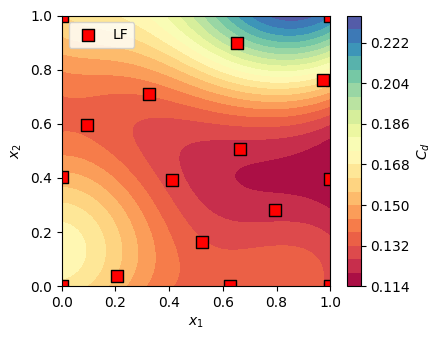

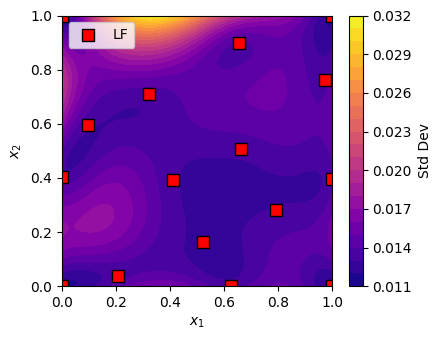

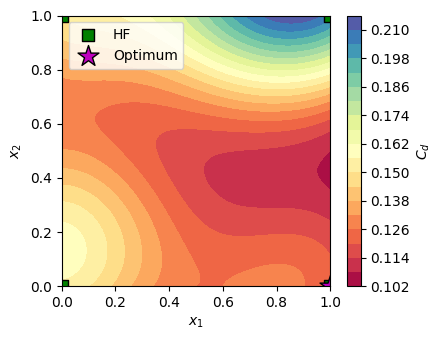

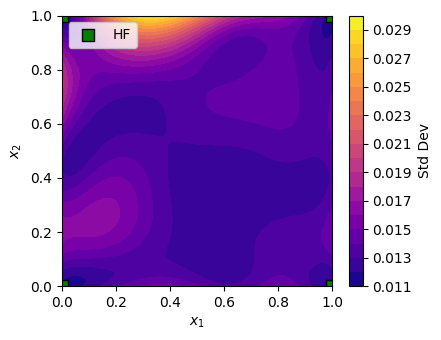

In [10]:
x1_plot = np.linspace(0, 1, 500)
x2_plot = np.linspace(0, 1, 500)
X1, X2 = np.meshgrid(x1_plot, x2_plot)
x_plot = np.column_stack([X1.ravel(), X2.ravel()])

x_plot_low = np.concatenate([np.atleast_2d(x_plot), np.zeros((x_plot.shape[0], 1))], axis=1)
x_plot_high = np.concatenate([np.atleast_2d(x_plot), np.ones((x_plot.shape[0], 1))], axis=1)

resultFolder = "optimisationResults"
os.makedirs(resultFolder, exist_ok=True)

def plot_model_initial(x_low, y_low, x_high, y_high):
    mean_low, var_low = model.predict(x_plot_low)
    mean_high, var_high = model.predict(x_plot_high)
    
    std_low = np.sqrt(var_low)
    std_high = np.sqrt(var_high)

    # --------------------------------------------------------
    # High-fidelity optimum (lowest Cd)
    # --------------------------------------------------------
    best_idx = np.argmin(y_high)
    best_x = x_high[best_idx]
    best_y = y_high[best_idx]

    # --------------------------------------------------------
    # Low-Fidelity Mean Plot
    # --------------------------------------------------------
    FIG_SIZE = (4.5, 3.5)
    fig1, ax1 = plt.subplots(figsize=FIG_SIZE)
    Z_low = mean_low.reshape(X1.shape)
    cf1 = ax1.contourf(X1, X2, Z_low, 20, cmap="Spectral", alpha=1)
    cbar1 = fig1.colorbar(cf1, ax=ax1)
    cbar1.set_label('$C_d$')

    ax1.scatter(x_low[:, 0], x_low[:, 1], marker='s', s=70, color='r', edgecolor='k', label='LF')
    ax1.set_xlabel('$x_1$')
    ax1.set_ylabel('$x_2$')
    ax1.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(resultFolder, 'LF_initialModel.svg'), format='svg', bbox_inches='tight')
    plt.show()

    # --------------------------------------------------------
    # Low-Fidelity Variance Plot
    # --------------------------------------------------------
    fig2, ax2 = plt.subplots(figsize=FIG_SIZE)
    Z_var_low = std_low.reshape(X1.shape)
    cf2 = ax2.contourf(X1, X2, Z_var_low, 20, cmap="plasma", alpha=1)
    cbar2 = fig2.colorbar(cf2, ax=ax2)
    cbar2.set_label('Std Dev')

    ax2.scatter(x_low[:, 0], x_low[:, 1], marker='s', s=70, color='r', edgecolor='k', label='LF')
    ax2.set_xlabel('$x_1$')
    ax2.set_ylabel('$x_2$')
    ax2.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(resultFolder, 'LF_sdInitial.svg'), format='svg', bbox_inches='tight')
    plt.show()

    # --------------------------------------------------------
    # High-Fidelity Mean Plot 
    # --------------------------------------------------------
    fig3, ax3 = plt.subplots(figsize=FIG_SIZE)
    Z_high = mean_high.reshape(X1.shape)
    cf3 = ax3.contourf(X1, X2, Z_high, 20, cmap="Spectral", alpha=1)
    cbar3 = fig3.colorbar(cf3, ax=ax3)
    cbar3.set_label('$C_d$')

    ax3.scatter(x_high[:, 0], x_high[:, 1], marker='s', s=70, color='green', edgecolor='k', label='HF')

    # --- Light-blue star marking best Cd ---
    ax3.scatter(best_x[0], best_x[1],
                marker='*', s=250, color='m', edgecolor='k', label='Optimum')

    ax3.set_xlabel('$x_1$')
    ax3.set_ylabel('$x_2$')
    ax3.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(resultFolder, 'HF_initialModel.svg'), format='svg', bbox_inches='tight')
    plt.show()

    # --------------------------------------------------------
    # High-Fidelity Variance Plot
    # --------------------------------------------------------
    fig4, ax4 = plt.subplots(figsize=FIG_SIZE)
    Z_var_high = std_high.reshape(X1.shape)
    cf4 = ax4.contourf(X1, X2, Z_var_high, 20, cmap="plasma", alpha=1)
    cbar4 = fig4.colorbar(cf4, ax=ax4)
    cbar4.set_label('Std Dev')

    ax4.scatter(x_high[:, 0], x_high[:, 1], marker='s', s=70, color='green', edgecolor='k', label='HF')
    ax4.set_xlabel('$x_1$')
    ax4.set_ylabel('$x_2$')
    ax4.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(resultFolder, 'HF_sdInitial.svg'), format='svg', bbox_inches='tight')
    plt.show()

plot_model_initial(x_low_norm, y_low, x_high_norm, y_high)

<table>
<tr>
<td align="center" width="50%">
<img src="img/LF_initialModel.svg" width="50%"><br>
<b>(a)</b> LF initial samplemean objective function prediction.
</td>
<td align="center" width="50%">
<img src="img/LF_sdInitial.svg" width="50%"><br>
<b>(b)</b> LF initial sample standard deviation.
</td>
</tr>

<tr>
<td align="center" width="50%">
<img src="img/HF_initialModel.svg" width="50%"><br>
<b>(c)</b> HF initial sample mean objective function prediction.
</td>
<td align="center" width="50%">
<img src="img/HF_sdInitial.svg" width="50%"><br>
<b>(d)</b> HF initial sample standard deviation.
</td>
</tr>
</table>

<p align="center">
<b>Figure 5.</b> The initial prediction of mean mean objective function and the associated standard deviation.
</p>

## 11. Defining the Acquisition Function

The code uses the MUMBO$^4$ acquisition function to choose the next sampling point. The acquisition function considers the surrogate model prediction, uncertainty, fidelity level, and simulation cost. Because high-fidelity simulations are more expensive, the acquisition value is divided by the cost of each fidelity. This helps the optimiser decide whether the next run should be low fidelity or high fidelity.

In [11]:
class Cost(Acquisition):
    def __init__(self, costs):
        self.costs = costs

    def evaluate(self, x):
        fidelity_index = x[:, -1].astype(int) 
        x_cost = np.array([self.costs[i] for i in fidelity_index])
        return x_cost[:, None]
    
    @property
    def has_gradients(self):
        return True
    
    def evaluate_with_gradients(self, x):
        return self.evalute(x), np.zeros(x.shape)

cost_acquisition = Cost([low_fidelity_cost, high_fidelity_cost])

acquisition = MUMBO(model, parameter_space, num_samples=5, grid_size=500) / cost_acquisition

## 12. Running the Optimisation Loop

The optimisation loop runs for the selected number of iterations, defined by `numberOfIteration`. At each iteration, the acquisition function selects a new design point and fidelity level. The selected simulation is then run, the drag coefficient is extracted, and the surrogate model is updated using the new data.

During the optimisation, the code searches the high-fidelity surrogate model over a grid of `x1` and `x2` values. It stores the predicted minimum high-fidelity drag value and its location.

In [12]:
initial_loop_state = create_loop_state(x_array, y_array)
acquisition_optimizer = MultiSourceAcquisitionOptimizer(GradientAcquisitionOptimizer(parameter_space), parameter_space)
candidate_point_calculator = SequentialPointCalculator(acquisition, acquisition_optimizer)
model_updater = FixedIntervalUpdater(model)
loop = OuterLoop(candidate_point_calculator, model_updater, initial_loop_state)

x1_search = np.linspace(0, 1, 500)  
x2_search = np.linspace(0, 1, 500)
X1_search, X2_search = np.meshgrid(x1_search, x2_search)

x_search = np.column_stack([X1_search.ravel(), X2_search.ravel()])

x_search_low = np.column_stack([x_search, np.zeros(x_search.shape[0])])  # Fidelity 0
x_search_high = np.column_stack([x_search, np.ones(x_search.shape[0])])  # Fidelity 1

model_min_mean = []
model_min_loc = []
model_min_HF = []

def calculate_metrics(loop, loop_state):
    mean_high, _ = loop.model_updaters[0].model.predict(x_search_high)

    min_index = np.argmin(mean_high) 
    model_min_mean.append(mean_high[min_index])
    model_min_loc.append(x_search_high[min_index, :-1])
    
    min_HF = np.min(mean_high)
    model_min_HF.append(min_HF)

loop.iteration_end_event.append(calculate_metrics)
loop.run_loop(objective_fcn, numberOfIteration)


Processing sample 1/1, x1 = 0.1, x2 = 0.059056064749264996
Processed x1 (before generating STL): 0.1, Type: <class 'numpy.float64'>
Processed x2 (before generating STL): 0.059056064749264996, Type: <class 'numpy.float64'>
prm file saved at: /home/y95228da/Desktop/AIRTUK/package-v1/airtuk-tutorials-main/tutorials/MFM_BO/optimisedCase/hemisphere_parameters.prm
 STL file saved successfully: /home/y95228da/Desktop/AIRTUK/package-v1/airtuk-tutorials-main/tutorials/MFM_BO/optimisedCase/constant/triSurface/hemisphere.stl
Calculated projected area in streamwise (X) direction: 0.006968 m^2
forceCoeffDict successfully written to:
   /home/y95228da/Desktop/AIRTUK/package-v1/airtuk-tutorials-main/tutorials/MFM_BO/optimisedCase/system/forceCoeffs
Aref updated to: 0.006968 m²
decomposeParDict successfully written to:
   /home/y95228da/Desktop/AIRTUK/package-v1/airtuk-tutorials-main/tutorials/MFM_BO/optimisedCase/system/decomposeParDict
numberOfSubdomains: 24
simpleCoeffs n: (12 2 1)
Using OpenFOAM: 

KeyboardInterrupt: 

## 13. Plotting the Final Surrogate Model

After the optimisation loop finishes, the code plots the final surrogate model. It creates final contour plots for the low-fidelity and high-fidelity predictions, together with uncertainty plots. The best high-fidelity sample is marked on the high-fidelity mean plot.

In [ ]:
is_high_fidelity = loop.loop_state.X[:, -1] == 1

def plot_model_final(x_low, y_low, x_high, y_high):
    mean_low, var_low = model.predict(x_plot_low)
    mean_high, var_high = model.predict(x_plot_high)
    
    std_low = np.sqrt(var_low) 
    std_high = np.sqrt(var_high)

    # --------------------------------------------------------
    # Find best (lowest) Cd among HIGH-FIDELITY samples
    # --------------------------------------------------------
    best_idx = np.argmin(y_high)
    best_x = x_high[best_idx] 
    best_y = y_high[best_idx]

    # --------------------------------------------------------
    # Low-Fidelity Mean Plot
    # --------------------------------------------------------
    FIG_SIZE = (5, 3.5)
    fig1, ax1 = plt.subplots(figsize=FIG_SIZE)
    Z_low = mean_low.reshape(X1.shape)
    cf1 = ax1.contourf(X1, X2, Z_low, 20, cmap="Spectral", alpha=1)
    cbar1 = fig1.colorbar(cf1, ax=ax1)
    cbar1.set_label('$C_d$')

    ax1.scatter(x_low[:, 0], x_low[:, 1], marker='s', s=70, color='r', edgecolor='k', label='LF')
    ax1.set_xlabel('$x_1$')
    ax1.set_ylabel('$x_2$')
    ax1.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(resultFolder, 'LF_finalModel.svg'), format='svg', bbox_inches='tight')

    # --------------------------------------------------------
    # Low-Fidelity Variance Plot
    # --------------------------------------------------------
    fig2, ax2 = plt.subplots(figsize=FIG_SIZE)
    Z_var_low = std_low.reshape(X1.shape)
    cf2 = ax2.contourf(X1, X2, Z_var_low, 20, cmap="plasma", alpha=1)
    cbar2 = fig2.colorbar(cf2, ax=ax2)
    cbar2.set_label('Std Dev')

    ax2.scatter(x_low[:, 0], x_low[:, 1], marker='s', s=70, color='r', edgecolor='k', label='LF')
    ax2.set_xlabel('$x_1$')
    ax2.set_ylabel('$x_2$')
    ax2.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(resultFolder, 'LF_sdFinal.svg'), format='svg', bbox_inches='tight')

    # --------------------------------------------------------
    # High-Fidelity Mean Plot
    # --------------------------------------------------------
    fig3, ax3 = plt.subplots(figsize=FIG_SIZE)
    Z_high = mean_high.reshape(X1.shape)
    cf3 = ax3.contourf(X1, X2, Z_high, 20, cmap="Spectral", alpha=1)
    cbar3 = fig3.colorbar(cf3, ax=ax3)
    cbar3.set_label('$C_d$')

    ax3.scatter(x_high[:, 0], x_high[:, 1], marker='s', s=70, color='green', edgecolor='k', label='HF')

    ax3.scatter(best_x[0], best_x[1],
                marker='*', s=250, color='m', edgecolor='k', label='Optimum')

    ax3.set_xlabel('$x_1$')
    ax3.set_ylabel('$x_2$')
    ax3.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(resultFolder, 'HF_finalModel.svg'), format='svg', bbox_inches='tight')

    # --------------------------------------------------------
    # High-Fidelity Variance Plot
    # --------------------------------------------------------
    fig4, ax4 = plt.subplots(figsize=FIG_SIZE)
    Z_var_high = std_high.reshape(X1.shape)
    cf4 = ax4.contourf(X1, X2, Z_var_high, 20, cmap="plasma", alpha=1)
    cbar4 = fig4.colorbar(cf4, ax=ax4)
    cbar4.set_label('Std Dev')

    ax4.scatter(x_high[:, 0], x_high[:, 1], marker='s', s=70, color='green', edgecolor='k', label='HF')
    ax4.set_xlabel('$x_1$')
    ax4.set_ylabel('$x_2$')
    ax4.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(resultFolder, 'HF_sdFinal.svg'), format='svg', bbox_inches='tight')
    plt.show

plot_model_final(x_low=loop.loop_state.X[~is_high_fidelity],
                 y_low=loop.loop_state.Y[~is_high_fidelity],
                 x_high=loop.loop_state.X[is_high_fidelity],
                 y_high=loop.loop_state.Y[is_high_fidelity])



<table>
<tr>
<td align="center" width="50%">
<img src="img/LF_finalModel.svg" width="50%"><br>
<b>(a)</b> LF final prediction.
</td>
<td align="center" width="50%">
<img src="img/LF_sdFinal.svg" width="50%"><br>
<b>(b)</b> LF final standard deviation.
</td>
</tr>

<tr>
<td align="center" width="50%">
<img src="img/HF_finalModel.svg" width="50%"><br>
<b>(c)</b> HF final prediction.
</td>
<td align="center" width="50%">
<img src="img/HF_sdFinal.svg" width="50%"><br>
<b>(d)</b> HF final standard deviation.
</td>
</tr>
</table>

<p align="center">
<b>Figure 6.</b> The final predicted objective function for both Low and High-Fidelity and their associated standard deviation.
</p>

## 14. Saving the Optimisation Data

This step saves the final low-fidelity and high-fidelity sample data into CSV files. It also saves all sampled points, their fidelity levels, objective values, and the best high-fidelity result.

In [ ]:
file_path = os.path.join(resultFolder, "finalModelLF.csv") 

x_low_norm = loop.loop_state.X[~is_high_fidelity][:, :2]
y_low_norm = loop.loop_state.Y[~is_high_fidelity]
x_high_norm = loop.loop_state.X[is_high_fidelity][:, :2]
y_high_norm = loop.loop_state.Y[is_high_fidelity]

x_low_real = unnormalize_nd(x_low_norm)
data_LF = {
    "xLF1_norm": x_low_norm[:, 0],
    "xLF2_norm": x_low_norm[:, 1],
    "xLF1_real": x_low_real[:, 0],
    "xLF2_real": x_low_real[:, 1],
    "yLF": y_low_real.flatten(),
}
df_LF = pd.DataFrame(data_LF)
df_LF.to_csv(file_path, index=False)
print(f"LF Data saved to: {file_path}")

# Save High-Fidelity Data
file_path = os.path.join(resultFolder, "finalModelHF.csv")
x_high_real = unnormalize_nd(x_high_norm)
data_HF = {
    "xHF1_norm": x_high_norm[:, 0],
    "xHF2_norm": x_high_norm[:, 1],
    "xHF1_real": x_high_real[:, 0],
    "xHF2_real": x_high_real[:, 1],
    "yHF": y_high_real.flatten(),
}
df_HF = pd.DataFrame(data_HF)
df_HF.to_csv(file_path, index=False)
print(f"HF Data saved to: {file_path}")


## 15. Plotting the Convergence

This part of the code plots the convergence history using the best high-fidelity drag coefficient found so far. It also plots how the sampled `x1` and `x2` locations change over the optimisation iterations.

In [ ]:
X_all = loop.loop_state.X 
Y_all = loop.loop_state.Y.flatten()
is_hf = X_all[:, -1] == 1        
is_lf = ~is_hf                   
iterations = np.arange(1, len(Y_all)+1)

# ======================================================
#   Running best-so-far (High-Fidelity only)
# ======================================================
best_so_far = np.full_like(iterations, fill_value=np.inf, dtype=float)
current_best = np.inf
for i in range(len(Y_all)):
    if is_hf[i]:
        if Y_all[i] < current_best:
            current_best = Y_all[i]
    best_so_far[i] = current_best

n_lf_initial_total = LFinitialSamples
n_hf_initial_total = HFinitialSamples

n_init_total = n_lf_initial_total + n_hf_initial_total
iterations = np.arange(1, X_all.shape[0] + 1)

# ======================================================
#   Plot Convergence Curve (Y_best)
# ======================================================
plt.figure(figsize=(7,6))
plt.step(iterations, best_so_far, where='post', color='blue', label="$HF_{best}$")

plt.scatter(iterations[is_lf], Y_all[is_lf], marker='s', color='red', label="$LF$")
plt.scatter(iterations[is_hf], Y_all[is_hf], marker='s', color='green', label="$HF$")

plt.axvspan(0.5, n_init_total+0.5, color='grey', alpha=0.15, label="$N_{init}$")
plt.xlabel("Iteration")
plt.ylabel("$C_d$")
plt.xlim(0.5, X_all.shape[0] + 0.5)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=4, frameon=True,fontsize='small')
plt.tight_layout()

file_path_conv = os.path.join(resultFolder, "ConvergenceStepPlot.svg")
plt.savefig(file_path_conv, format="svg", bbox_inches="tight")
print(f"Convergence plot saved to: {file_path_conv}")

# ======================================================
#   Save all samples (LF + HF)
# ======================================================
file_path_all = os.path.join(resultFolder, "AllSamples.csv")

df = pd.DataFrame({
    "Iteration": iterations,
    "x1_norm": X_all[:, 0],
    "x2_norm": X_all[:, 1],
    "Fidelity": np.where(is_hf, "HF", "LF"),
    "y": Y_all
})

best_idx = np.argmin(Y_all[is_hf])
best_x1 = X_all[is_hf, 0][best_idx]
best_x2 = X_all[is_hf, 1][best_idx]
best_y  = Y_all[is_hf][best_idx]

print(f"Best HF objective: {best_y:.4f} at x1_norm = {best_x1:.4f}, x2_norm = {best_x2:.4f}")


summary_row = pd.DataFrame({
    "Iteration": ["Best"],
    "x1_norm": [best_x1],
    "x2_norm": [best_x2],
    "Fidelity": ["HF"],
    "y": [best_y]
})
df = pd.concat([df, summary_row], ignore_index=True)
df.to_csv(file_path_all, index=False)
print(f"All samples + best result saved to: {file_path_all}")

# ======================================================
#   Save sampled locations (both real & normalised for convenience)
# ======================================================
file_path_x_csv = os.path.join(resultFolder, "SampledLocations2D.csv")
X_design = unnormalize_nd(X_all[:, :2])
df_x = pd.DataFrame({
    "Iteration": iterations,
    "x1_real": X_design[:, 0],
    "x2_real": X_design[:, 1],
    "x1_norm": X_all[:, 0],
    "x2_norm": X_all[:, 1],
    "Fidelity": np.where(is_hf, "HF", "LF")
})
df_x.to_csv(file_path_x_csv, index=False)
print(f"Sampled 2D locations saved to: {file_path_x_csv}")


## 16. Optimisation Results

The figures below compare the predicted objective function and the associated standard deviation, drag coefficient comparison, geometry comparison, and flow field comparison between the baseline and optimised designs.

<div style="text-align: center;">
    <img src="img/ConvergenceStepPlot.svg" width="400">
    <p style="text-align: center;"><b>Figure 7.</b> Optimisation convergence. The shaded area indicates the initial samples. The overall sampling history shows that fewer expensive high-fidelity data are required to find the optimum $C_d$. The total computational time required to run the optimisation (4 LF samples and 6 HF samples) is about 70 minutes.</p>
</div>


| Geometry | $C_d$ |
| :--- | :--- |
| Baseline | 0.176 |
| Optimised | 0.086 (51.1% reduction) |



<div style="text-align: center;">
    <img src="img/comparison.png" width="1000">
    <p style="text-align: center;"><b>Figure 8.</b> The geometry comparison is shown at the top, while the streamwise velocity contour and turbulence kinetic energy comparison are shown on the left and right, respectively. These results compare the baseline and optimised designs.</p>
</div>



## References
1. Paleyes, A., Mahsereci, M., & Lawrence, N. D. (2023, July). Emukit: A Python toolkit for decision making under uncertainty. In Proceedings of the Python in Science Conference (Vol. 67). https://github.com/EmuKit/emukit
2. Tezzele, M., Demo, N., Mola, A., & Rozza, G. (2021). PyGeM: Python geometrical morphing. Software impacts, 7, 100047. https://github.com/mathlab/pygem
3. GPy: A Gaussian process framework in python (2022). http://github.com/SheffieldML/GPy
4. Moss, H. B., Leslie, D. S., & Rayson, P. (2020, September). Mumbo: Multi-task max-value bayesian optimization. In Joint European Conference on Machine Learning and Knowledge Discovery in Databases (pp. 447-462). Cham: Springer International Publishing. https://link.springer.com/chapter/10.1007/978-3-030-67664-3_27
